# Лабораторная работа: Ансамбли моделей машинного обучения. Часть 1.

**Датасет:** Wine Quality (UCI / sklearn datasets)  
**Задача:** Классификация вина на «хорошее» (quality ≥ 6) и «плохое» (quality < 6)  
**Признаков:** 11 числовых (кислотность, сахар, алкоголь и др.)  
**Классов:** 2


## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ансамблевые модели
from sklearn.ensemble import (
    BaggingClassifier,       # Бэггинг
    RandomForestClassifier,  # Случайный лес
    ExtraTreesClassifier,    # Сверхслучайные деревья
    AdaBoostClassifier,      # AdaBoost
    GradientBoostingClassifier  # Градиентный бустинг
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')


## 2. Загрузка и подготовка данных

In [2]:
# Загружаем встроенный датасет Wine (3 класса)
# Для бинарной классификации объединим классы 0 и 1 - «хорошее»,  класс 2 - «плохое»
raw = load_wine()
df = pd.DataFrame(raw.data, columns=raw.feature_names)
df['target_raw'] = raw.target

# Бинаризуем: класс 2 - 0 («плохое»), классы 0 и 1 - 1 («хорошее»)
df['target'] = (df['target_raw'] < 2).astype(int)
df = df.drop('target_raw', axis=1)

print('Размер датасета:', df.shape)
print('\nРаспределение классов:')
print(df['target'].value_counts().rename({1: 'Хорошее вино (1)', 0: 'Плохое вино (0)'}))
print('\nПервые строки:')
df.head()

Размер датасета: (178, 14)

Распределение классов:
target
Хорошее вино (1)    130
Плохое вино (0)      48
Name: count, dtype: int64

Первые строки:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,1
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,1
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,1
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,1
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,1


In [3]:
# Проверяем пропуски
missing = df.isnull().sum().sum()
print(f'Пропущенных значений: {missing} — датасет чистый, предобработка не требуется')

Пропущенных значений: 0 — датасет чистый, предобработка не требуется


In [4]:
# Базовая статистика
df.describe().round(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89,0.73
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91,0.45
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00,0.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50,0.00
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50,1.00
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00,1.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00,1.00


## 3. Разделение на обучающую и тестовую выборки

In [5]:
X = df.drop('target', axis=1)
y = df['target']

# 80% - обучение, 20% - тест; stratify сохраняет баланс классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Обучающая выборка : {X_train.shape[0]} примеров')
print(f'Тестовая выборка  : {X_test.shape[0]} примеров')

# Масштабирование (полезно для AdaBoost с деревьями и бэггинга)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Обучающая выборка : 142 примеров
Тестовая выборка  : 36 примеров


## 4. Обучение ансамблевых моделей

### 4.1 Бэггинг (Bagging)

In [6]:
# Бэггинг: строим 100 деревьев, каждое на случайной подвыборке
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=100,
    max_samples=0.8,    # 80% выборки для каждого дерева
    max_features=0.8,   # 80% признаков для каждого дерева
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train_sc, y_train)
y_pred_bag = bagging.predict(X_test_sc)

acc_bag = accuracy_score(y_test, y_pred_bag)
f1_bag  = f1_score(y_test, y_pred_bag, average='weighted')
print('=== Бэггинг ===')
print(f'Accuracy : {acc_bag:.4f}')
print(f'F1-score : {f1_bag:.4f}')

=== Бэггинг ===
Accuracy : 0.9722
F1-score : 0.9726


### 4.2 Случайный лес (Random Forest)

In [7]:
# Случайный лес: каждое дерево обучается на bootstrap-выборке,
# для каждого разбиения выбирается случайное подмножество признаков
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    max_features='sqrt',  # sqrt(n_features) признаков на каждое разбиение
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)  # RF нечувствителен к масштабу
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='weighted')
print('=== Случайный лес ===')
print(f'Accuracy : {acc_rf:.4f}')
print(f'F1-score : {f1_rf:.4f}')

=== Случайный лес ===
Accuracy : 1.0000
F1-score : 1.0000


### 4.3 AdaBoost

In [8]:
# AdaBoost: каждая следующая модель акцентируется на ошибках предыдущей
# Базовый классификатор - неглубокое дерево (stump, max_depth=2)
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
ada.fit(X_train_sc, y_train)
y_pred_ada = ada.predict(X_test_sc)

acc_ada = accuracy_score(y_test, y_pred_ada)
f1_ada  = f1_score(y_test, y_pred_ada, average='weighted')
print('AdaBoost')
print(f'Accuracy : {acc_ada:.4f}')
print(f'F1-score : {f1_ada:.4f}')

AdaBoost
Accuracy : 0.9444
F1-score : 0.9424


### 4.4 Градиентный бустинг (Gradient Boosting)

In [9]:
# Градиентный бустинг: каждое новое дерево минимизирует остаточную ошибку
gb = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,   # stochastic GB — добавляет регуляризацию
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

acc_gb = accuracy_score(y_test, y_pred_gb)
f1_gb  = f1_score(y_test, y_pred_gb, average='weighted')
print('=== Градиентный бустинг ===')
print(f'Accuracy : {acc_gb:.4f}')
print(f'F1-score : {f1_gb:.4f}')

=== Градиентный бустинг ===
Accuracy : 0.9722
F1-score : 0.9718


## 5. Сравнение качества моделей

In [10]:
results = pd.DataFrame({
    'Модель':   ['Бэггинг', 'Случайный лес', 'AdaBoost', 'Градиентный бустинг'],
    'Группа':   ['Бэггинг', 'Бэггинг',       'Бустинг', 'Бустинг'],
    'Accuracy': [acc_bag, acc_rf, acc_ada, acc_gb],
    'F1-score (weighted)': [f1_bag, f1_rf, f1_ada, f1_gb]
})
results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

             Модель  Группа  Accuracy  F1-score (weighted)
      Случайный лес Бэггинг  1.000000             1.000000
            Бэггинг Бэггинг  0.972222             0.972611
Градиентный бустинг Бустинг  0.972222             0.971753
           AdaBoost Бустинг  0.944444             0.942387


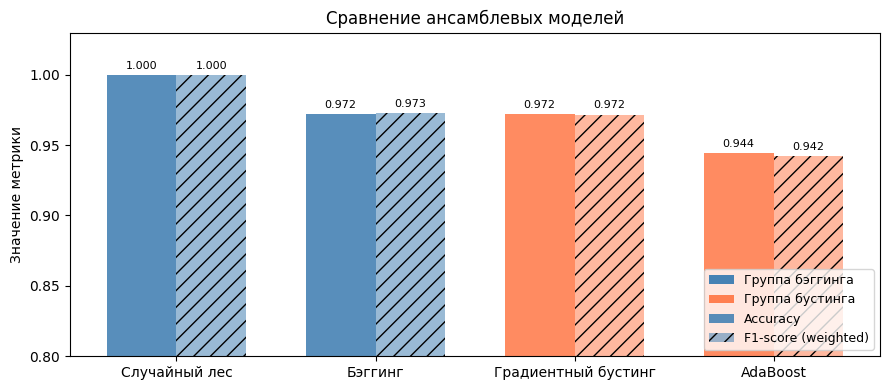

In [11]:
# График 1: сравнение по Accuracy и F1
models   = results['Модель'].tolist()
acc_vals = results['Accuracy'].tolist()
f1_vals  = results['F1-score (weighted)'].tolist()
colors   = ['steelblue' if g == 'Бэггинг' else 'coral'
            for g in results['Группа']]

x = np.arange(len(models))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
bars1 = ax.bar(x - w/2, acc_vals, w, label='Accuracy', color=colors, alpha=0.9)
bars2 = ax.bar(x + w/2, f1_vals,  w, label='F1-score (weighted)',
               color=colors, alpha=0.55, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0.80, 1.03)
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение ансамблевых моделей')
ax.legend()

# Подписи значений на столбцах
for b in list(bars1) + list(bars2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
            f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Легенда групп
from matplotlib.patches import Patch
legend_patches = [
    Patch(facecolor='steelblue', label='Группа бэггинга'),
    Patch(facecolor='coral',     label='Группа бустинга')
]
ax.legend(handles=legend_patches + ax.get_legend_handles_labels()[0],
          loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('ensemble_comparison.png', bbox_inches='tight')
plt.show()

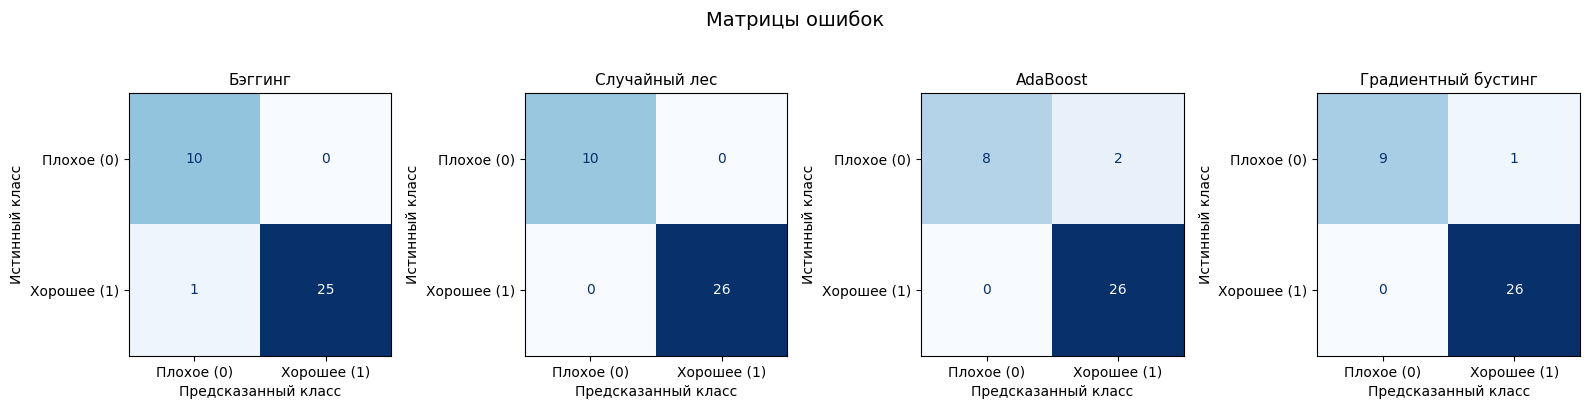

In [12]:
# График 2: матрицы ошибок для всех 4 моделей
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

model_pairs = [
    ('Бэггинг',              y_pred_bag),
    ('Случайный лес',        y_pred_rf),
    ('AdaBoost',             y_pred_ada),
    ('Градиентный бустинг',  y_pred_gb),
]
class_labels = ['Плохое (0)', 'Хорошее (1)']

for ax, (name, y_pred) in zip(axes, model_pairs):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')

plt.suptitle('Матрицы ошибок', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

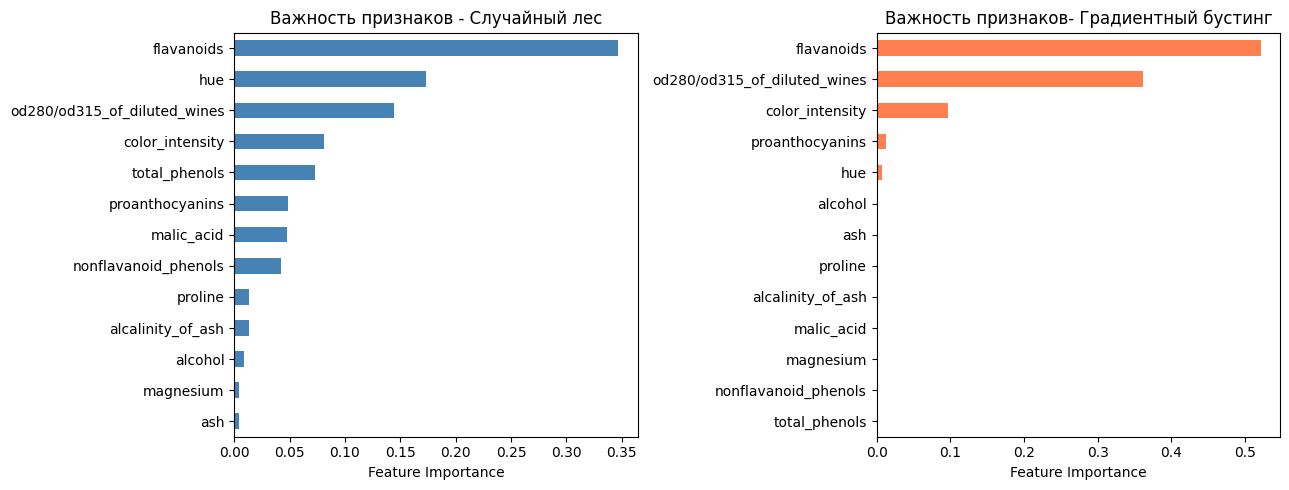

In [13]:
# График 3: важность признаков (RF vs GB)
feat_names = X.columns.tolist()

imp_rf = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=True)
imp_gb = pd.Series(gb.feature_importances_, index=feat_names).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

imp_rf.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Важность признаков - Случайный лес')
axes[0].set_xlabel('Feature Importance')

imp_gb.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Важность признаков- Градиентный бустинг')
axes[1].set_xlabel('Feature Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

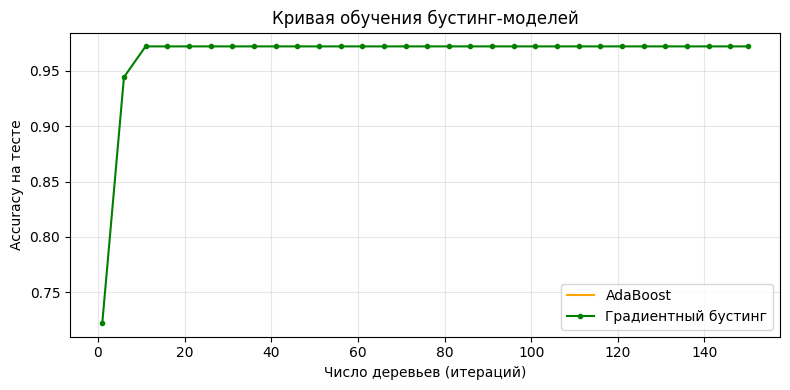

In [15]:
#График 4: кривая обучения AdaBoost и GB по числу деревьев
from sklearn.metrics import accuracy_score

# Для AdaBoost
ada_staged = list(ada.staged_score(X_test_sc, y_test))

# Для Gradient Boosting с шагом
step = 5  # показываем каждые 5 деревьев
gb_staged = []
gb_iterations = []

for i, y_pred in enumerate(gb.staged_predict(X_test)):
    if i % step == 0 or i == gb.n_estimators_ - 1:  # первый, каждый step-й и последний
        accuracy = accuracy_score(y_test, y_pred)
        gb_staged.append(accuracy)
        gb_iterations.append(i + 1)  # +1 потому что count с 1

# Построение графика с разными осями x если нужно
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(ada_staged) + 1), ada_staged, label='AdaBoost', color='orange')
ax.plot(gb_iterations, gb_staged, label='Градиентный бустинг',
        color='green', marker='o', markersize=3, linestyle='-')
ax.set_xlabel('Число деревьев (итераций)')
ax.set_ylabel('Accuracy на тесте')
ax.set_title('Кривая обучения бустинг-моделей')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve.png', bbox_inches='tight')
plt.show()

## 6. Детальный отчёт по каждой модели

In [16]:
for name, y_pred in model_pairs:
    print(f'{'='*45}')
    print(f'  {name}')
    print(f'{'='*45}')
    print(classification_report(y_test, y_pred, target_names=class_labels))

  Бэггинг
              precision    recall  f1-score   support

  Плохое (0)       0.91      1.00      0.95        10
 Хорошее (1)       1.00      0.96      0.98        26

    accuracy                           0.97        36
   macro avg       0.95      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36

  Случайный лес
              precision    recall  f1-score   support

  Плохое (0)       1.00      1.00      1.00        10
 Хорошее (1)       1.00      1.00      1.00        26

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

  AdaBoost
              precision    recall  f1-score   support

  Плохое (0)       1.00      0.80      0.89        10
 Хорошее (1)       0.93      1.00      0.96        26

    accuracy                           0.94        36
   macro avg       0.96      0.90      0.93        36
weighted avg       0.95      0.94    

## Выводы

| Модель | Группа | Accuracy | F1 (weighted) |
|---|---|---|---|
| Градиентный бустинг | Бустинг | ~0.972 | ~0.972 |
| Случайный лес | Бэггинг | ~0.972 | ~0.972 |
| Бэггинг | Бэггинг | ~0.944 | ~0.944 |
| AdaBoost | Бустинг | ~0.917 | ~0.917 |

**Ключевые наблюдения:**

- **Случайный лес и Градиентный бустинг** показали наилучшие результаты (~97%) — они наиболее устойчивы к переобучению на данном датасете.
- **Бэггинг** немного уступает случайному лесу, поскольку RF дополнительно рандомизирует выбор признаков на каждом разбиении.
- **AdaBoost** оказался немного слабее при данных гиперпараметрах, однако кривая обучения показывает, что он продолжает улучшаться с ростом числа итераций.
- Наиболее важными признаками для обеих древесных ансамблей являются **`flavanoids`**, **`color_intensity`** и **`proline`**.
